# *Libraries*

In [25]:
from typing import TypedDict, List

from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_community.document_loaders import PyPDFLoader


from langgraph.graph import StateGraph, START, END

# *AI*

In [26]:
llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

# *Document*

In [ ]:
loader = PyPDFLoader("doc.pdf")
document = loader.load()

# *Defining Schema*

In [4]:
from typing import TypedDict

class AgentState(TypedDict):

    # User Information
    name: str
    introduction: str

    # Document Understanding
    docs_summary: str

    # Topic System
    topics: list[str]
    selected_topic: str

    # Scope Selection
    scope_choice: str

    # Subtopic System
    subtopics: list[str]
    selected_subtopic: str

    # Question Type
    question_type: str

    # Generated Questions
    mcq_questions: str
    theory_questions: str

# *Greeting Node*

In [5]:
def greeting_node(state : AgentState) -> AgentState:
    """"This function simply greet the user and tell about what agent do"""

    state["introduction"] = f"Hello {state["name"]}, I am here to help you with practicing your desire topic"

    return state

# *Documents Summary Node*

In [6]:

def create_doc_summary(llm, document, state: AgentState) -> AgentState:
    splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
    chunks = splitter.split_text(document)

    summaries = []

    for chunk in chunks:
        prompt = f"""
Summarize the following content into key topics and key concepts:

{chunk}

Keep it short and structured.
"""
        response = llm.invoke(prompt).content
        summaries.append(response)

    final_prompt = f"""
Combine these summaries into a concise list of topics:

{summaries}
"""

    final_summary = llm.invoke(final_prompt).content

    return {
        **state,
        "docs_summary": final_summary
    }

# *Topic Suggestions Node*

In [7]:
def topic_suggestions_node(state : AgentState) -> AgentState:

    docs_summary = state["docs_summary"]

    prompt = f"""
From this study material:

{docs_summary}

Generate:
- 5 to 7 learning topics
- short topic names only 

Return as comma-separated List.
"""
    response = llm.invoke(prompt).content
    topics = [t.strip() for t in response.split(",")]

    return {
        **state,
        "topics" : topics
    }

# *Topic Selection Node*

In [8]:
def topic_selection_node(state: AgentState) -> AgentState:

    selected_topic = state["selected_topic"]

    print(f"You selected: {selected_topic}")

    choice = input(
        "Do you want:\n"
        "1. Full Topic\n"
        "2. Subtopics\n"
    )

    if choice == "1":
        scope = "full"

    else:
        scope = "subtopic"

    return {
        **state,
        "scope_choice": scope
    }

# *SubTopic Selection Node*

In [9]:
def subtopic_node(state: AgentState) -> AgentState:

    selected_topic = state["selected_topic"]

    prompt = f"""
You are helping a student practice questions.

Topic:
{selected_topic}

Task:
Generate 5 important subtopics for this topic.

Rules:
- Keep names short
- Return ONLY comma-separated subtopics
- No numbering
- No explanations
"""

    response = llm.invoke(prompt).content

    subtopics = [
        subtopic.strip()
        for subtopic in response.split(",")
    ]

    return {
        **state,
        "subtopics": subtopics
    }

In [10]:
def route_topic_scope(state: AgentState):

    if state["scope_choice"] == "full":
        return "question_node"

    return "subtopic_node"

# *Question Type Node*

In [11]:
def question_type_node(state : AgentState) -> AgentState:

    print(
        "Which type of questions do you want?\n" 
        "1. MCQ's\n" 
        "2. Theory Questions"
    )

    choice = input("Enter you choice: ")

    if choice == "1":
        question_type = "mcq"
    else:
        question_type = "theory"

    return {
        **state,
        "question_type" : question_type
    }

In [12]:
def router_question_type(state : AgentState) -> AgentState:
    
    if state["question_type"] == "mcq":
        return "mcq_node"
    
    return "theory_node"

# *MCQ's Node*

In [13]:
def mcq_node(state: AgentState) -> AgentState:

    # CASE 1 → Full topic
    if state["scope_choice"] == "full":

        topic_context = f"""
Topic: {state["selected_topic"]}
"""

    # CASE 2 → Subtopic
    else:

        topic_context = f"""
Topic: {state["selected_topic"]}

Subtopic: {state["selected_subtopic"]}
"""

    prompt = f"""
You are an AI teacher.

Generate 5 MCQs based on:

{topic_context}

Rules:
- 4 options each
- Mention correct answer
- Medium difficulty
"""

    response = llm.invoke(prompt).content

    return {
        **state,
        "mcq_questions": response
    }

# *Theory Questions Node*

In [14]:
def theory_node(state: AgentState) -> AgentState:

    # CASE 1 → Full Topic
    if state["scope_choice"] == "full":

        topic_context = f"""
Topic: {state["selected_topic"]}
"""

    # CASE 2 → Subtopic
    else:

        topic_context = f"""
Topic: {state["selected_topic"]}

Subtopic: {state["selected_subtopic"]}
"""

    prompt = f"""
You are an AI teacher.

Generate 3 theory questions based on:

{topic_context}

Rules:
- Generate detailed conceptual questions
- Generate answers also
- Each answer should be between 50 and 100 words
- Keep questions medium difficulty
- Format clearly
"""

    response = llm.invoke(prompt).content

    return {
        **state,
        "theory_questions": response
    }

In [18]:
graph = StateGraph(AgentState)

graph.add_node("greeting_node", greeting_node)
graph.add_node("document_summary_node", create_doc_summary)
graph.add_node("topic_suggestion_node", topic_suggestions_node)
graph.add_node("topic_selection_node", topic_selection_node)
graph.add_node("subtopic_selection_node", subtopic_node)
graph.add_node("question_type_node", question_type_node)
graph.add_node("mcq_questions_node", mcq_node)
graph.add_node("theory_questions_node", theory_node)

graph.add_edge(START, "greeting_node")
graph.add_edge("greeting_node", "document_summary_node")
graph.add_edge("document_summary_node", "topic_suggestion_node")
graph.add_edge("topic_suggestion_node", "topic_selection_node")

# CONDITIONAL ROUTING
graph.add_conditional_edges(
    "topic_selection_node",
    route_topic_scope,
    {
        "question_type_node": "question_type_node",
        "subtopic_selection_node": "subtopic_selection_node"
    }
)

graph.add_edge("subtopic_selection_node", "question_type_node")

# QUESTION TYPE ROUTING
graph.add_conditional_edges(
    "question_type_node",
    router_question_type,
    {
        "mcq_questions_node": "mcq_questions_node",
        "theory_questions_node": "theory_questions_node"
    }
)

graph.add_edge("mcq_questions_node", END)
graph.add_edge("theory_questions_node", END)

agent = graph.compile()

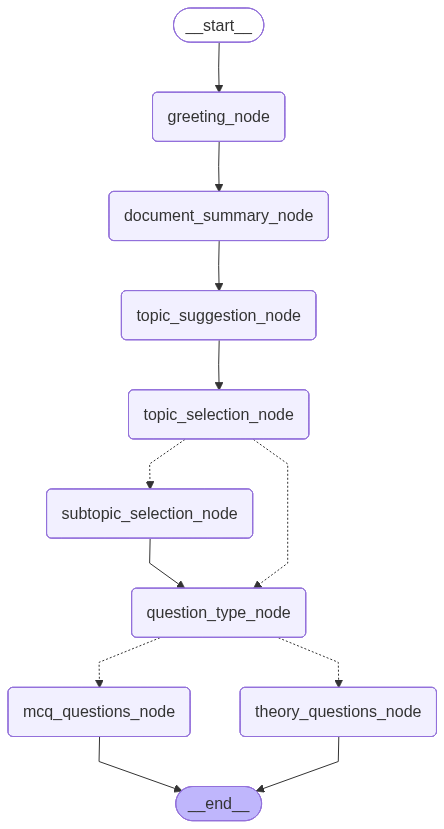

In [19]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))